# I. Model inference test and convertation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import warnings
warnings.simplefilter('ignore')

from os import path
import os
import sys
sys.path.append(path.abspath('..'))

In [3]:
import onnxruntime as ort
import onnx
import numpy as np
import torch

from typing import Tuple
from numpy.typing import NDArray
from torch import Tensor

import random
import matplotlib.pyplot as plt
import jpeg4py as jpeg
import cv2 
import typing as tp
from pathlib import Path
import time

import albumentations as albu
from albumentations.pytorch import ToTensorV2

from src.lightning_module import FirstBreaksModule
from configs.config import Config

In [4]:
DEVICE = 'cpu'
NN_THRESHOLD = 0.7
ONNX_MODEL_NAME = '../experiments/exp1/exp1.onnx'
BATCH_SIZE = 1
NRUNS=2000
STEP=500

# Available ONNX providers
print(ort.get_available_providers())
ONNX_PROVIDERS = [
    'CUDAExecutionProvider',
    'CPUExecutionProvider',
]

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [5]:
class ONNXRuntimeWrapper:
    """Wrapper for ONNX model for inference speed test"""
    def __init__(self, ort_session: tp.Any) -> None:
        self.session = ort_session
        self.input_name = [input_.name for input_ in ort_session.get_inputs()][0]

    def predict(self, input_data: NDArray[np.uint8]) -> NDArray[np.uint8]:
        return self.session.run(None, {self.input_name: input_data})[0]

In [6]:
def denormalize(
    img: NDArray[float],
    mean: Tuple[float, ...] = (0.485, 0.456, 0.406),
    std: Tuple[float, ...] = (0.229, 0.224, 0.225),
    max_value: int = 255,
) -> NDArray[int]:
    denorm = albu.Normalize(
        mean=tuple([-me / st for me, st in zip(mean, std)]),  # noqa: WPS221
        std=tuple([1.0 / st for st in std]),
        max_pixel_value=1.0,
        p=1.0,
    )
    denorm_img = denorm(image=img)['image'] * max_value
    return denorm_img.astype(np.uint8)


def tensor_to_cv_image(tensor: Tensor) -> NDArray[float]:
    return tensor.permute(1, 2, 0).cpu().numpy()


def onnx_preprocessing(
    raw_image: NDArray[np.uint8],
    image_size=(224, 224)
) -> NDArray[np.uint8]:
    # resize
    raw_image = cv2.resize(raw_image.copy(), image_size, interpolation=cv2.INTER_LINEAR)

    # normalize
    mean = np.array((0.485, 0.456, 0.406), dtype=np.float32) * 255.0
    std = np.array((0.229, 0.224, 0.225), dtype=np.float32) * 255.0
    denominator = np.reciprocal(std, dtype=np.float32)
    raw_image = raw_image.astype(np.float32)
    raw_image -= mean
    raw_image *= denominator

    # transpose
    raw_image = raw_image.transpose((2, 0, 1))[None]
    return raw_image


def benchmark(
    model: tp.Any,
    input_shape: Tuple[int] = (1, 1, 224, 224),
    nwarmup: int = 50,
    nruns: int = 10000,  # 2000
    print_step: int = 1000,  # 500
    prefiks: str = '',
) -> None:
    input_data = np.random.rand(*input_shape).astype(np.float32)

    print("Warm up ...")
    for _ in range(nwarmup):
        input_data = np.random.rand(*input_shape).astype(np.float32)
        features = model.predict(input_data)

    print("Start timing ...")
    timings = []
    for i in range(1, nruns + 1):
        input_data = np.random.rand(*input_shape).astype(np.float32)
        start_time = time.time()
        features = model.predict(input_data)
        end_time = time.time()
        timings.append(end_time - start_time)
        if i % print_step == 0:
            print(
                f'Iteration {i}/{nruns}, avg batch time {np.mean(timings) * 1000:.2f} ± {np.std(timings) * 1000:.2f} ms.'
            )

    print(f'Input shape: {input_data.shape}')
    print(f'{prefiks} Average throughput: {input_shape[0] / np.mean(timings):.2f} images/second')

## 1. Evaluate model for spectra set No 1

In [7]:
# Load best checkpoint
checkpoint = '../experiments/exp1/epoch_epoch=12-val_iou=0.967.ckpt'
new_model = FirstBreaksModule.load_from_checkpoint(checkpoint, config=Config.from_yaml('../configs/config.yaml'))
new_model.eval()
new_model.to(DEVICE)

Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [8]:
test_imgs_num = 100
imgs_path = Path('../data/spec_1/images')
masks_path = Path('../data/spec_1/masks')

images_spec = []
while len(images_spec) < test_imgs_num:
    random_mask_name = random.choice(os.listdir(masks_path))
    img_id = random_mask_name.split('_')[0]
    feat_time, time_break, img_shape, trace_shape = random_mask_name.split('_')[1].split('-')
    # feat_time = time_break * (img.shape[1] / y_data.shape[0])
    image = jpeg.JPEG(imgs_path / f"{img_id}.jpg").decode()
    mask = cv2.imread(
        str(masks_path / random_mask_name),
        cv2.IMREAD_GRAYSCALE
    )
    images_spec.append([image, mask, feat_time, time_break, img_shape, trace_shape])

print(f'Loaded: {len(images_spec)} images')

Loaded: 100 images


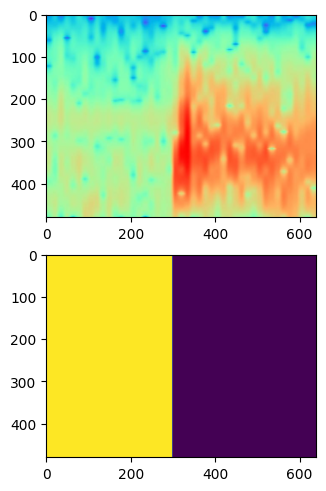

In [9]:
# Spectrogram rendering:
fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[0][0])
axes[1].imshow(images_spec[0][1])
plt.show()

In [97]:
# Test output
transforms = albu.Compose([
    albu.Resize(height=256, width=256),
    albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=1.0
    ),
    ToTensorV2()
])

time_break_errors = []
pred_breaks = []
pred_masks = []
for img_data in images_spec:
    out_img = transforms(
        image=img_data[0]
    )["image"]

    pr_mask = new_model(out_img.to(DEVICE).unsqueeze(0))
    pr_mask = (pr_mask.squeeze().cpu().detach().numpy().round())
    pr_mask = np.exp(-np.logaddexp(0, -pr_mask))  # sigmoid
    pr_mask[pr_mask >= NN_THRESHOLD] = 255
    pr_mask[pr_mask < NN_THRESHOLD] = 0
    _ = pr_mask.astype(np.uint8)

    # Resize the image
    resized_image = cv2.resize(
        pr_mask,
        (img_data[0].shape[1], img_data[0].shape[0]),
        interpolation=cv2.INTER_NEAREST_EXACT
    )
    pred_masks.append(resized_image)

    if int(np.sum(pr_mask)) == 0:
        pred_breaks.append(0)
        continue

    pred_feat_break = np.where(
        np.sum((resized_image != 0), axis=0) > 0
    )[-1][-1] + 1

    pred_break = pred_feat_break * int(img_data[-1]) / int(img_data[-2])
    pred_breaks.append(pred_break)
    time_break_errors.append(
        np.abs(float(img_data[-3]) - pred_break) / float(img_data[-3]) * 100
    )


In [98]:
print(f"Average rel. error: {np.mean(time_break_errors)} %, std: {np.std(time_break_errors)}")

Average rel. error: 2.4409413238588065 %, std: 3.5695274580634155


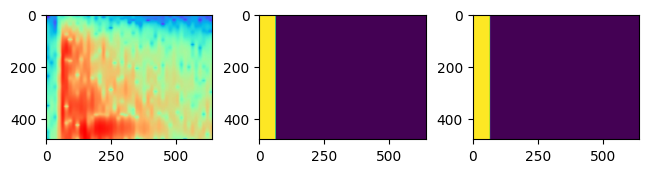

In [99]:
# Result visual evaluation:
random_index = random.randint(0, len(images_spec))

fig, axes = plt.subplots(1, 3, constrained_layout=True)
axes[0].imshow(images_spec[random_index][0])
axes[1].imshow(images_spec[random_index][1])
axes[2].imshow(pred_masks[random_index])
plt.show()

## 2. Evaluate model for spectra set No 2

In [49]:
# Load best checkpoint
checkpoint = '../experiments/exp2/epoch_epoch=11-val_iou=0.967.ckpt'
new_model = FirstBreaksModule.load_from_checkpoint(checkpoint, config=Config.from_yaml('../configs/config.yaml'))
new_model.eval()
new_model.to(DEVICE)

Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [52]:
test_imgs_num = 100
imgs_path = Path('../data/spec_2/images')
masks_path = Path('../data/spec_2/masks')

images_spec = []
while len(images_spec) < test_imgs_num:
    random_mask_name = random.choice(os.listdir(masks_path))
    img_id = random_mask_name.split('_')[0]
    feat_time, time_break, img_shape, trace_shape = random_mask_name.split('_')[1].split('-')
    # feat_time = time_break * (img.shape[1] / y_data.shape[0])
    image = jpeg.JPEG(imgs_path / f"{img_id}.jpg").decode()
    mask = cv2.imread(
        str(masks_path / random_mask_name),
        cv2.IMREAD_GRAYSCALE
    )
    images_spec.append([image, mask, feat_time, time_break, img_shape, trace_shape])

print(f'Loaded: {len(images_spec)} images')

Loaded: 100 images


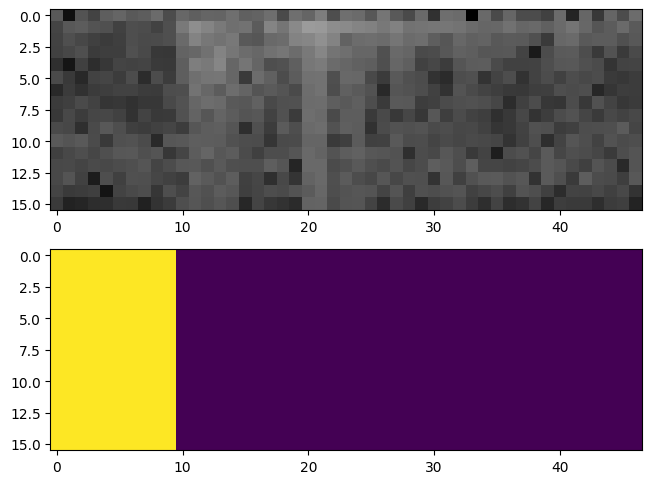

In [53]:
# Spectrogram rendering:
fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[0][0])
axes[1].imshow(images_spec[0][1])
plt.show()

In [61]:
# Test output
transforms = albu.Compose([
    albu.Resize(height=64, width=64),
    albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=1.0
    ),
    ToTensorV2()
])

time_break_errors = []
pred_breaks = []
pred_masks = []
for img_data in images_spec:
    out_img = transforms(
        image=img_data[0]
    )["image"]

    pr_mask = new_model(out_img.to(DEVICE).unsqueeze(0))
    pr_mask = (pr_mask.squeeze().cpu().detach().numpy().round())
    pr_mask = np.exp(-np.logaddexp(0, -pr_mask))  # sigmoid
    pr_mask[pr_mask >= NN_THRESHOLD] = 255
    pr_mask[pr_mask < NN_THRESHOLD] = 0
    _ = pr_mask.astype(np.uint8)

    # Resize the image
    resized_image = cv2.resize(
        pr_mask,
        (img_data[0].shape[1], img_data[0].shape[0]),
        interpolation=cv2.INTER_NEAREST_EXACT
    )
    pred_masks.append(resized_image)

    if int(np.sum(pr_mask)) == 0:
        pred_breaks.append(0)
        continue

    pred_feat_break = np.where(
        np.sum((resized_image != 0), axis=0) > 0
    )[-1][-1] + 1

    pred_break = pred_feat_break * int(img_data[-1]) / int(img_data[-2])
    pred_breaks.append(pred_break)
    time_break_errors.append(
        np.abs(float(img_data[-3]) - pred_break) / float(img_data[-3]) * 100
    )

In [62]:
print(f"Average rel. error: {np.mean(time_break_errors)} %, std: {np.std(time_break_errors)}")

Average rel. error: 13.206026125529243 %, std: 37.6744639973698


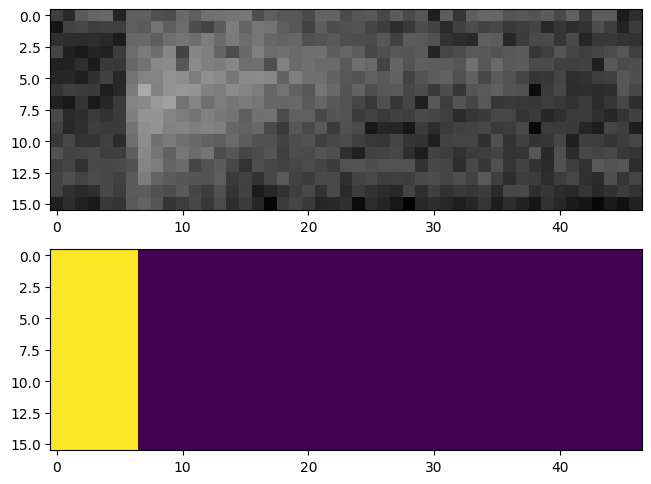

In [65]:
# Result visual evaluation:
random_index = random.randint(0, len(images_spec))

fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[random_index][0])
axes[1].imshow(pred_masks[random_index])
plt.show()

## 3. Evaluate model for spectra set No3

In [66]:
# Load best checkpoint
checkpoint = '../experiments/exp3/epoch_epoch=06-val_iou=0.966.ckpt'
new_model = FirstBreaksModule.load_from_checkpoint(checkpoint, config=Config.from_yaml('../configs/config.yaml'))
new_model.eval()
new_model.to(DEVICE)

Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [67]:
test_imgs_num = 100
imgs_path = Path('../data/spec_3/images')
masks_path = Path('../data/spec_3/masks')

images_spec = []
while len(images_spec) < test_imgs_num:
    random_mask_name = random.choice(os.listdir(masks_path))
    img_id = random_mask_name.split('_')[0]
    feat_time, time_break, img_shape, trace_shape = random_mask_name.split('_')[1].split('-')
    # feat_time = time_break * (img.shape[1] / y_data.shape[0])
    image = jpeg.JPEG(imgs_path / f"{img_id}.jpg").decode()
    mask = cv2.imread(
        str(masks_path / random_mask_name),
        cv2.IMREAD_GRAYSCALE
    )
    images_spec.append([image, mask, feat_time, time_break, img_shape, trace_shape])

print(f'Loaded: {len(images_spec)} images')

Loaded: 100 images


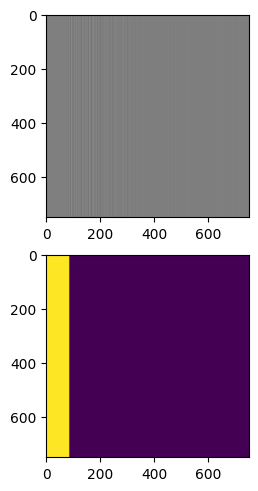

In [68]:
# Spectrogram rendering:
fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[0][0])
axes[1].imshow(images_spec[0][1])
plt.show()

In [69]:
# Test output
transforms = albu.Compose([
    albu.Resize(height=256, width=256),
    albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=1.0
    ),
    ToTensorV2()
])

time_break_errors = []
pred_breaks = []
pred_masks = []
for img_data in images_spec:
    out_img = transforms(
        image=img_data[0]
    )["image"]

    pr_mask = new_model(out_img.to(DEVICE).unsqueeze(0))
    pr_mask = (pr_mask.squeeze().cpu().detach().numpy().round())
    pr_mask = np.exp(-np.logaddexp(0, -pr_mask))  # sigmoid
    pr_mask[pr_mask >= NN_THRESHOLD] = 255
    pr_mask[pr_mask < NN_THRESHOLD] = 0
    _ = pr_mask.astype(np.uint8)

    # Resize the image
    resized_image = cv2.resize(
        pr_mask,
        (img_data[0].shape[1], img_data[0].shape[0]),
        interpolation=cv2.INTER_NEAREST_EXACT
    )
    pred_masks.append(resized_image)

    if int(np.sum(pr_mask)) == 0:
        pred_breaks.append(0)
        continue

    pred_feat_break = np.where(
        np.sum((resized_image != 0), axis=0) > 0
    )[-1][-1] + 1

    pred_break = pred_feat_break
    pred_breaks.append(pred_break)
    time_break_errors.append(
        np.abs(float(img_data[-3]) - pred_break) / float(img_data[-3]) * 100
    )

In [70]:
print(f"Average rel. error: {np.mean(time_break_errors)} %, std: {np.std(time_break_errors)}")

Average rel. error: 14.038027808627977 %, std: 80.79661826996187


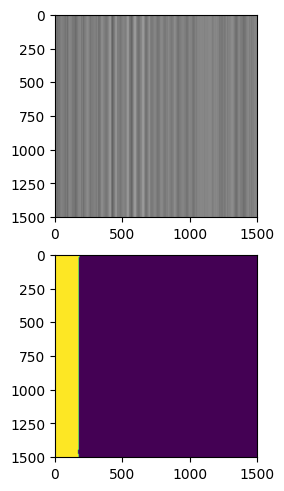

In [73]:
# Result visual evaluation:
random_index = random.randint(0, len(images_spec))

fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[random_index][0])
axes[1].imshow(pred_masks[random_index])
plt.show()

## 4. Evaluate model for spectra set No 4

In [76]:
# Load best checkpoint
checkpoint = '../experiments/exp4/epoch_epoch=11-val_iou=0.958.ckpt'
new_model = FirstBreaksModule.load_from_checkpoint(checkpoint, config=Config.from_yaml('../configs/config.yaml'))
new_model.eval()
new_model.to(DEVICE)

Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [78]:
test_imgs_num = 100
imgs_path = Path('../data/spec_4/images')
masks_path = Path('../data/spec_4/masks')

images_spec = []
while len(images_spec) < test_imgs_num:
    random_mask_name = random.choice(os.listdir(masks_path))
    img_id, time_break, _ = random_mask_name.split('_')
    image = jpeg.JPEG(imgs_path / f"{img_id}.jpg").decode()
    mask = cv2.imread(
        str(masks_path / random_mask_name),
        cv2.IMREAD_GRAYSCALE
    )
    images_spec.append([image, mask, feat_time, time_break, img_shape, trace_shape])

print(f'Loaded: {len(images_spec)} images')

Loaded: 100 images


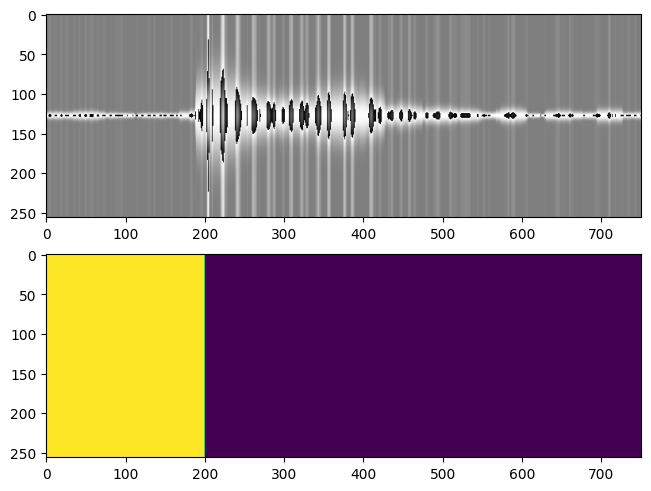

In [79]:
# Spectrogram rendering:
fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[0][0])
axes[1].imshow(images_spec[0][1])
plt.show()

In [80]:
# Test output
transforms = albu.Compose([
    albu.Resize(height=256, width=256),
    albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=1.0
    ),
    ToTensorV2()
])

time_break_errors = []
pred_breaks = []
pred_masks = []
for img_data in images_spec:
    out_img = transforms(
        image=img_data[0]
    )["image"]

    pr_mask = new_model(out_img.to(DEVICE).unsqueeze(0))
    pr_mask = (pr_mask.squeeze().cpu().detach().numpy().round())
    pr_mask = np.exp(-np.logaddexp(0, -pr_mask))  # sigmoid
    pr_mask[pr_mask >= NN_THRESHOLD] = 255
    pr_mask[pr_mask < NN_THRESHOLD] = 0
    _ = pr_mask.astype(np.uint8)

    # Resize the image
    resized_image = cv2.resize(
        pr_mask,
        (img_data[0].shape[1], img_data[0].shape[0]),
        interpolation=cv2.INTER_NEAREST_EXACT
    )
    pred_masks.append(resized_image)

    if int(np.sum(pr_mask)) == 0:
        pred_breaks.append(0)
        continue

    pred_feat_break = np.where(
        np.sum((resized_image != 0), axis=0) > 0
    )[-1][-1] + 1

    pred_break = pred_feat_break
    pred_breaks.append(pred_break)
    time_break_errors.append(
        np.abs(float(img_data[-3]) - pred_break) / float(img_data[-3]) * 100
    )

In [81]:
print(f"Average rel. error: {np.mean(time_break_errors)} %, std: {np.std(time_break_errors)}")

Average rel. error: 6.916501578409305 %, std: 31.691644764143334


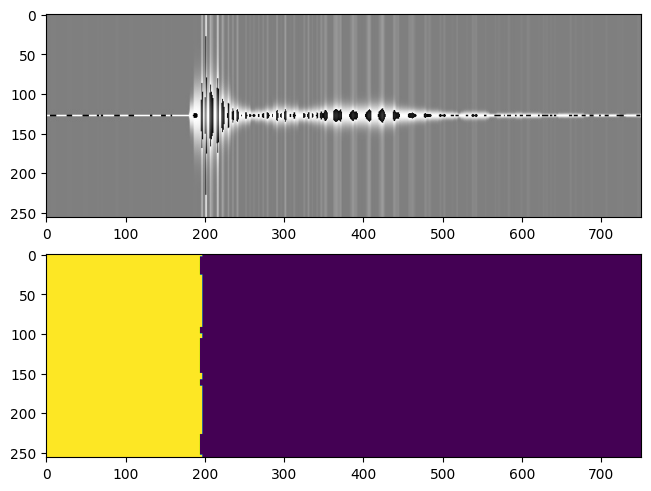

In [82]:
# Result visual evaluation:
random_index = random.randint(0, len(images_spec))

fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[random_index][0])
axes[1].imshow(pred_masks[random_index])
plt.show()

## 5. Evaluate model for spectra set No5

In [83]:
# Load best checkpoint
checkpoint = '../experiments/exp5/epoch_epoch=14-val_iou=0.820.ckpt'
new_model = FirstBreaksModule.load_from_checkpoint(checkpoint, config=Config.from_yaml('../configs/config.yaml'))
new_model.eval()
new_model.to(DEVICE)

Unexpected keys (classifier.bias, classifier.weight, conv_head.weight, norm_head.bias, norm_head.num_batches_tracked, norm_head.running_mean, norm_head.running_var, norm_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

FirstBreaksModule(
  (_model): Unet(
    (encoder): TimmUniversalEncoder(
      (model): MobileNetV3Features(
        (conv_stem): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (blocks): Sequential(
          (0): Sequential(
            (0): EdgeResidual(
              (conv_exp): Conv2d(24, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (bn1): BatchNormAct2d(
                96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): ReLU(inplace=True)
              )
              (aa): Identity()
              (se): Identity()
              (conv_pwl): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn2): BatchNormAct2d(
                48, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [84]:
test_imgs_num = 100
imgs_path = Path('../data/spec_5/images')
masks_path = Path('../data/spec_5/masks')

images_spec = []
while len(images_spec) < test_imgs_num:
    random_mask_name = random.choice(os.listdir(masks_path))
    img_id = random_mask_name.split('_')[0]
    image = jpeg.JPEG(imgs_path / f"{img_id}.jpg").decode()
    mask = cv2.imread(
        str(masks_path / random_mask_name),
        cv2.IMREAD_GRAYSCALE
    )
    images_spec.append([image, mask])

print(f'Loaded: {len(images_spec)} images')

Loaded: 100 images


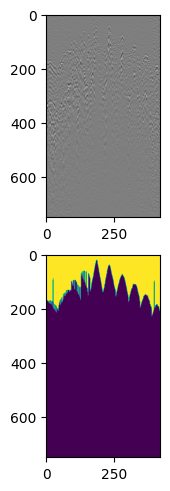

In [85]:
# Spectrogram rendering:
fig, axes = plt.subplots(2, 1, constrained_layout=True)
axes[0].imshow(images_spec[0][0])
axes[1].imshow(images_spec[0][1])
plt.show()

In [87]:
# Test output
transforms = albu.Compose([
    albu.Resize(height=256, width=256),
    albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=1.0
    ),
    ToTensorV2()
])

time_break_errors = np.array([])
pred_masks = []
for img_data in images_spec:
    out_img = transforms(
        image=img_data[0]
    )["image"]

    pr_mask = new_model(out_img.to(DEVICE).unsqueeze(0))
    pr_mask = (pr_mask.squeeze().cpu().detach().numpy().round())
    pr_mask = np.exp(-np.logaddexp(0, -pr_mask))  # sigmoid
    pr_mask[pr_mask >= NN_THRESHOLD] = 255
    pr_mask[pr_mask < NN_THRESHOLD] = 0
    _ = pr_mask.astype(np.uint8)

    # Resize the image
    resized_mask = cv2.resize(
        pr_mask,
        (img_data[0].shape[1], img_data[0].shape[0]),
        interpolation=cv2.INTER_NEAREST_EXACT
    )
    pred_masks.append(resized_mask)

    if int(np.sum(pr_mask)) == 0:
        pred_breaks.append(0)
        continue

    time_break_errors = np.append(
        time_break_errors,
        np.count_nonzero(
            np.abs(img_data[1] - resized_mask),
            axis=0
        ) / img_data[0].shape[0] * 100
    )


In [88]:
print(f"Average rel. error: {np.mean(time_break_errors)} %, std: {np.std(time_break_errors)}")

Average rel. error: 33.600007278595264 %, std: 24.016108554685516


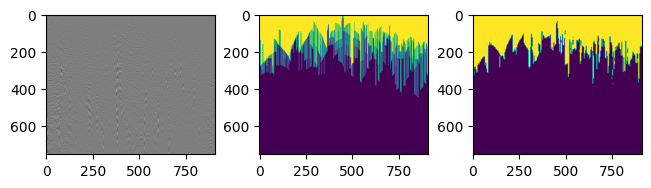

In [92]:
# Result visual evaluation:
random_index = random.randint(0, len(images_spec))

fig, axes = plt.subplots(1, 3, constrained_layout=True)
axes[0].imshow(images_spec[random_index][0])
axes[1].imshow(images_spec[random_index][1])
axes[2].imshow(pred_masks[random_index])
plt.show()

# Convert to ONNX best model

In [10]:
dummy_input = torch.rand(1, 3, 256, 256, device=DEVICE)
torch.onnx.export(
    new_model,
    dummy_input,
    ONNX_MODEL_NAME,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes = {'input': [0], 'output': [0]}, # dinamic batch
)

In [11]:
# Check converted model
onnx_model = onnx.load(ONNX_MODEL_NAME)
onnx.checker.check_model(onnx_model)
print(onnx.helper.printable_graph(onnx_model.graph))

graph main_graph (
  %input[FLOAT, input_dynamic_axes_1x3x256x256]
) initializers (
  %_model.segmentation_head.0.weight[FLOAT, 1x16x3x3]
  %_model.segmentation_head.0.bias[FLOAT, 1]
  %onnx::Conv_1083[FLOAT, 24x3x3x3]
  %onnx::Conv_1084[FLOAT, 24]
  %onnx::Conv_1086[FLOAT, 96x24x3x3]
  %onnx::Conv_1087[FLOAT, 96]
  %onnx::Conv_1089[FLOAT, 48x96x1x1]
  %onnx::Conv_1090[FLOAT, 48]
  %onnx::Conv_1092[FLOAT, 48x1x3x3]
  %onnx::Conv_1093[FLOAT, 48]
  %onnx::Conv_1095[FLOAT, 192x48x1x1]
  %onnx::Conv_1096[FLOAT, 192]
  %onnx::Conv_1098[FLOAT, 192x1x5x5]
  %onnx::Conv_1099[FLOAT, 192]
  %onnx::Conv_1101[FLOAT, 96x192x1x1]
  %onnx::Conv_1102[FLOAT, 96]
  %onnx::Conv_1104[FLOAT, 96x1x3x3]
  %onnx::Conv_1105[FLOAT, 96]
  %onnx::Conv_1107[FLOAT, 384x96x1x1]
  %onnx::Conv_1108[FLOAT, 384]
  %onnx::Conv_1110[FLOAT, 384x1x3x3]
  %onnx::Conv_1111[FLOAT, 384]
  %onnx::Conv_1113[FLOAT, 96x384x1x1]
  %onnx::Conv_1114[FLOAT, 96]
  %onnx::Conv_1116[FLOAT, 96x1x3x3]
  %onnx::Conv_1117[FLOAT, 96]
  %onnx::

## 1. Test ONNX inference

In [12]:
# Init ONNX session
ort_session = ort.InferenceSession(
    ONNX_MODEL_NAME,
    providers=ONNX_PROVIDERS
)

print(f'{[input_.name for input_ in ort_session.get_inputs()]}')
print(f'{[output_.name for output_ in ort_session.get_outputs()]}')

['input']
['output']


In [13]:
# Prepare input tensor
image = images_spec[0][0]
onnx_input = onnx_preprocessing(image, image_size=(256, 256))
onnx_input = np.concatenate([onnx_input] * BATCH_SIZE)

ort_inputs = {ort_session.get_inputs()[0].name: onnx_input}
print(list(ort_inputs.keys()))

['input']


In [14]:
# Run ONNX
ort_outputs = ort_session.run(None, ort_inputs)[0]
print(ort_outputs.shape)

pr_mask = (ort_outputs.squeeze().round())
print(pr_mask.shape)

(1, 1, 256, 256)
(256, 256)


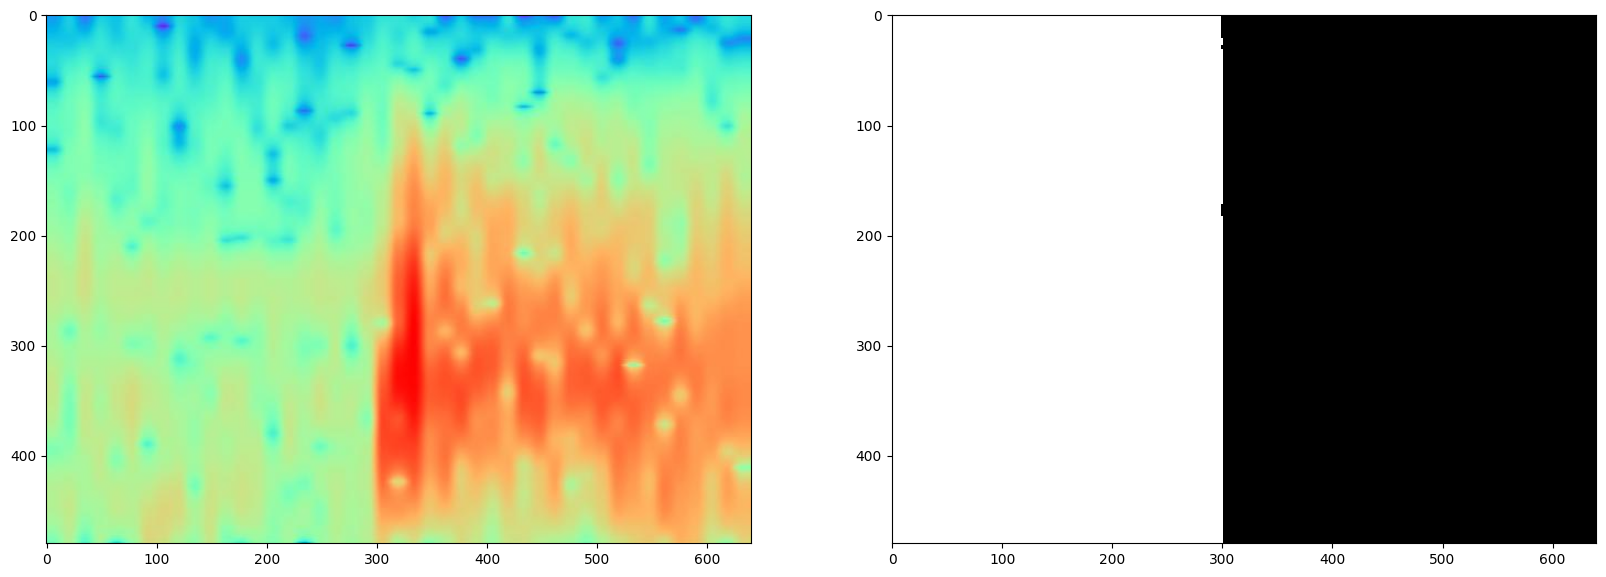

In [16]:
# resize
pr_mask = np.exp(-np.logaddexp(0, -pr_mask))  # sigmoid
pr_mask[pr_mask >= NN_THRESHOLD] = 255
pr_mask[pr_mask < NN_THRESHOLD] = 0
_ = pr_mask.astype(np.uint8)

# Resize the image
resized_mask = cv2.resize(
    pr_mask,
    (image.shape[1], image.shape[0]),
    interpolation=cv2.INTER_NEAREST_EXACT
)

plt.rcParams['figure.figsize'] = [20, 10]
f, axarr = plt.subplots(1, 2) 

axarr[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axarr[1].imshow(resized_mask, cmap='gray', vmin=0, vmax=1)

Inference is the same as for pure model - check pass.

## 2. Calculate ONNX inference FPS

In [17]:
for provider in ONNX_PROVIDERS:
    print(f"{provider}: {ONNX_MODEL_NAME}")

    ort_session = ort.InferenceSession(
        ONNX_MODEL_NAME,
        providers=[provider]
    )
    ort_wrapper = ONNXRuntimeWrapper(ort_session)
    benchmark(ort_wrapper, (BATCH_SIZE, 3, 256, 256), nruns=NRUNS, print_step=STEP, prefiks=f"{provider}: {ONNX_MODEL_NAME}")
    print()

CUDAExecutionProvider: ../experiments/exp1/exp1.onnx
Warm up ...


2025-04-28 19:47:17.923589740 [W:onnxruntime:, session_state.cc:1166 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2025-04-28 19:47:17.923609961 [W:onnxruntime:, session_state.cc:1168 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


Start timing ...
Iteration 500/2000, avg batch time 5.28 ± 0.29 ms.
Iteration 1000/2000, avg batch time 5.28 ± 0.21 ms.
Iteration 1500/2000, avg batch time 5.30 ± 0.18 ms.
Iteration 2000/2000, avg batch time 5.32 ± 0.17 ms.
Input shape: (1, 3, 256, 256)
CUDAExecutionProvider: ../experiments/exp1/exp1.onnx Average throughput: 188.13 images/second

CPUExecutionProvider: ../experiments/exp1/exp1.onnx
Warm up ...
Start timing ...
Iteration 500/2000, avg batch time 25.80 ± 0.71 ms.
Iteration 1000/2000, avg batch time 25.40 ± 0.86 ms.
Iteration 1500/2000, avg batch time 25.25 ± 0.84 ms.
Iteration 2000/2000, avg batch time 25.22 ± 0.82 ms.
Input shape: (1, 3, 256, 256)
CPUExecutionProvider: ../experiments/exp1/exp1.onnx Average throughput: 39.65 images/second

